In [39]:
%load_ext autoreload
%autoreload 2

import blochK.jax as jblochK
import blochK

import blochK.jax.library_hamiltonians
import blochK.hamiltonian_testing

import jax.numpy as jnp
import numpy as np
from numpy import pi,cos,sin,exp

import matplotlib.pyplot as plt
import matplotlib

import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
# Hjax = jblochK.library_hamiltonians.create_Hsquare()
# Hnp = blochK.hamiltonian_testing.create_Hsquare()

Hjax = jblochK.library_hamiltonians.create_Haldane()
Hnp = blochK.hamiltonian_testing.create_Haldane()


In [41]:
# Grid sizes to benchmark
Lk_values = np.logspace(1, np.log10(1000), 20, base=10).astype(int)
repeats = 3

def time_call(func, *args, **kwargs):
    t0 = time.perf_counter()
    out = func(*args, **kwargs)
    # JAX executes asynchronously, so force synchronization for accurate timing.
    if hasattr(out, "block_until_ready"):
        out.block_until_ready()
    t1 = time.perf_counter()
    return t1 - t0

# Warm-up JAX once to exclude compilation from the sweep.
_warmup = jblochK.observable.conductivity(Hjax, Lk=Lk_values[0])
if hasattr(_warmup, "block_until_ready"):
    _warmup.block_until_ready()

times_jax = []
times_np = []

for Lk in Lk_values:
    t_jax = min(time_call(jblochK.observable.conductivity, Hjax, Lk=Lk) for _ in range(repeats))
    t_np = min(time_call(blochK.observable.conductivity, Hnp, Lk=Lk) for _ in range(repeats))
    times_jax.append(t_jax)
    times_np.append(t_np)
    print(f"Lk={Lk:>3} | JAX={t_jax:.4f}s | NumPy={t_np:.4f}s")

times_jax = np.array(times_jax)
times_np = np.array(times_np)

Lk= 10 | JAX=0.0143s | NumPy=0.0009s
Lk= 12 | JAX=0.0124s | NumPy=0.0010s
Lk= 16 | JAX=0.0128s | NumPy=0.0013s
Lk= 20 | JAX=0.0121s | NumPy=0.0016s
Lk= 26 | JAX=0.0142s | NumPy=0.0023s
Lk= 33 | JAX=0.0143s | NumPy=0.0032s
Lk= 42 | JAX=0.0159s | NumPy=0.0052s
Lk= 54 | JAX=0.0186s | NumPy=0.0076s
Lk= 69 | JAX=0.0312s | NumPy=0.0158s
Lk= 88 | JAX=0.0670s | NumPy=0.0253s
Lk=112 | JAX=0.0520s | NumPy=0.0355s
Lk=143 | JAX=0.0817s | NumPy=0.0603s
Lk=183 | JAX=0.0947s | NumPy=0.0812s
Lk=233 | JAX=0.1438s | NumPy=0.1317s
Lk=297 | JAX=0.2267s | NumPy=0.2131s
Lk=379 | JAX=0.3681s | NumPy=0.3385s
Lk=483 | JAX=0.6029s | NumPy=0.5778s
Lk=615 | JAX=0.9924s | NumPy=0.9557s
Lk=784 | JAX=1.6371s | NumPy=1.5248s
Lk=1000 | JAX=2.8908s | NumPy=2.5798s


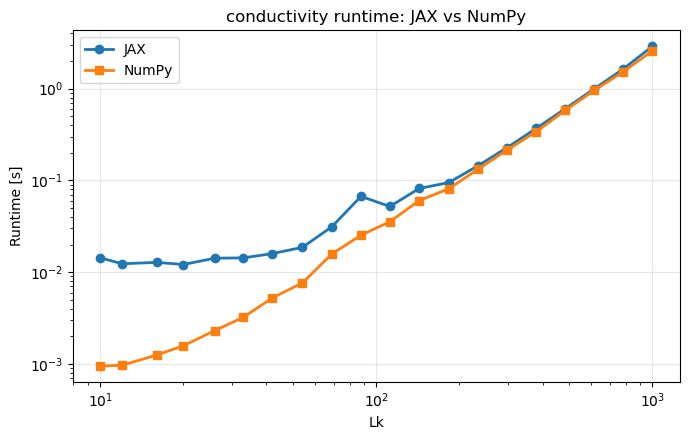

In [42]:
plt.figure(figsize=(7, 4.5))
plt.plot(Lk_values, times_jax, marker="o", linewidth=2, label="JAX")
plt.plot(Lk_values, times_np, marker="s", linewidth=2, label="NumPy")
plt.xlabel("Lk")
plt.ylabel("Runtime [s]")
plt.title("conductivity runtime: JAX vs NumPy")
plt.xscale("log")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()